Kent Lin Chan

20202132

Se usó Python 3.14.2

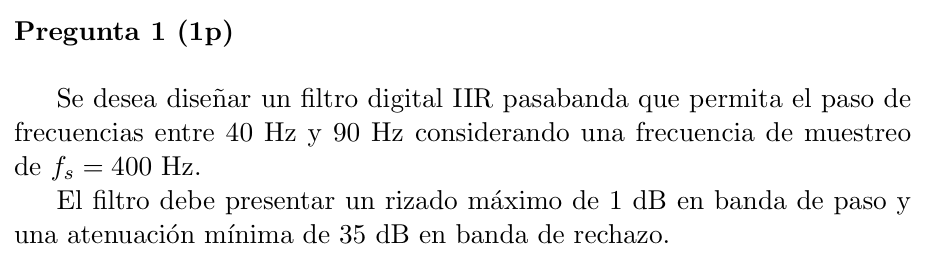

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
%matplotlib inline

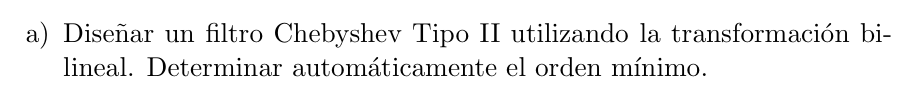

**Marco teórico.** Un filtro Chebyshev Tipo II (o Chebyshev inverso) presenta respuesta **monótona en la banda de paso** y **equiripple en la banda de rechazo**. Su función de transferencia tiene ceros sobre el eje $j\Omega$ (frecuencias de rechazo) y polos en el semiplano izquierdo del plano $s$. La respuesta en magnitud al cuadrado cumple:

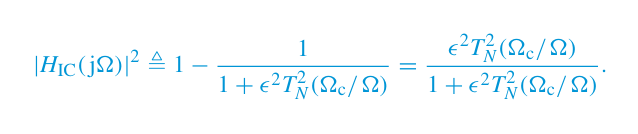

donde $T_n(\cdot)$ es el polinomio de Chebyshev de orden $n$, $\Omega_s$ es la frecuencia de la banda de rechazo y $\varepsilon$ controla la atenuación mínima en la banda de rechazo:
$$\varepsilon = \sqrt{10^{A_s/10} - 1}$$
con $A_s$ la atenuación mínima en dB.

In [38]:
fs = 400
fpass = np.array([40.0, 90.0])
gpass = 1
gstop = 35

delta_f = 10
fstop = np.array([fpass[0] - delta_f, fpass[1] + delta_f])

print(f"Frecuencia de muestreo:        fs = {fs} Hz")
print(f"Banda de paso:                 fpass = {fpass} Hz")
print(f"Banda de rechazo (bordes):     fstop = {fstop} Hz")
print(f"Rizado en banda de paso:       gpass = {gpass} dB")
print(f"Atenuación en banda rechazo:   gstop = {gstop} dB")

Frecuencia de muestreo:        fs = 400 Hz
Banda de paso:                 fpass = [40. 90.] Hz
Banda de rechazo (bordes):     fstop = [ 30. 100.] Hz
Rizado en banda de paso:       gpass = 1 dB
Atenuación en banda rechazo:   gstop = 35 dB


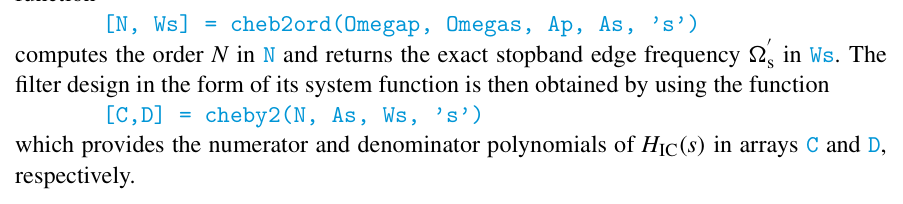

In [39]:
# Orden mínimo del filtro Chebyshev Tipo II
n_orden, Wn = signal.cheb2ord(fpass, fstop, gpass, gstop, fs=fs)

print(f"Orden mínimo del filtro:       n = {n_orden}")
print(f"Frecuencia(s) natural(es):     Wn = {Wn} Hz")

Orden mínimo del filtro:       n = 7
Frecuencia(s) natural(es):     Wn = [35.19741751 98.59432501] Hz


In [40]:
b, a = signal.cheby2(n_orden, gstop, fpass, btype='bandpass', fs=fs)

print(f"Coeficientes del numerador b ({len(b)} coefs):")
print(np.round(b, 6))
print(f"\nCoeficientes del denominador a ({len(a)} coefs):")
print(np.round(a, 6))

Coeficientes del numerador b (15 coefs):
[ 0.026629 -0.129582  0.32221  -0.550792  0.710885 -0.67944   0.413401
  0.       -0.413401  0.67944  -0.710885  0.550792 -0.32221   0.129582
 -0.026629]

Coeficientes del denominador a (15 coefs):
[ 1.0000000e+00 -6.0227010e+00  1.9366662e+01 -4.2454136e+01
  7.0086404e+01 -9.1277465e+01  9.6236665e+01 -8.3148146e+01
  5.9099982e+01 -3.4383460e+01  1.6159225e+01 -5.9714130e+00
  1.6546730e+00 -3.1069200e-01  3.1221000e-02]


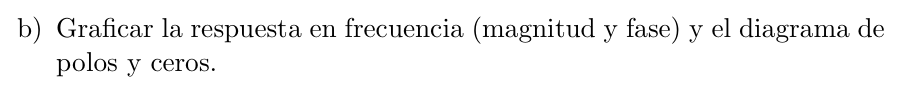

In [41]:
# Polos, ceros y ganancia
z, p, k = signal.tf2zpk(b, a)

print(f"Número de polos: {len(p)}")
print(f"Número de ceros: {len(z)}")
print(f"Ganancia:        {k:.6f}")
print(f"\nTodos los polos dentro del círculo unitario: {np.all(np.abs(p) < 1)}")
print(f"Todos los ceros sobre el círculo unitario:    {np.allclose(np.abs(z), 1)}")

Número de polos: 14
Número de ceros: 14
Ganancia:        0.026629

Todos los polos dentro del círculo unitario: True
Todos los ceros sobre el círculo unitario:    True


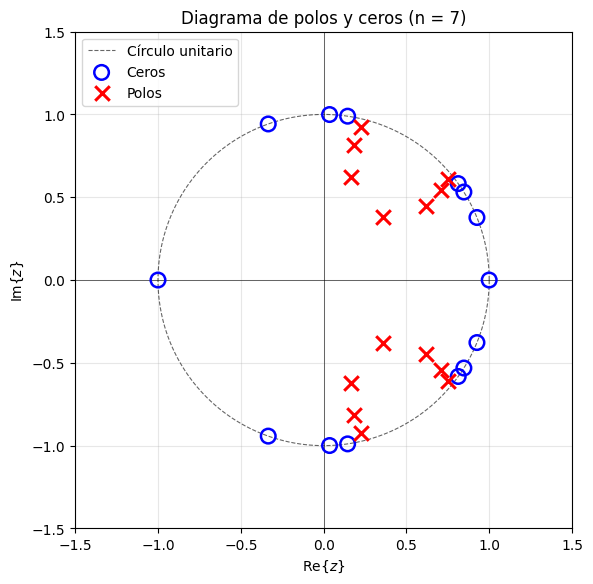

In [42]:
def planoz(z, p, ax=None, title='Diagrama de polos y ceros'):
    """Grafica polos (x) y ceros (o) sobre el plano z con el círculo unitario."""
    if ax is None:
        fig, ax = plt.subplots(figsize=[6, 6])
    
    # Círculo unitario
    theta = np.linspace(0, 2*np.pi, 400)
    ax.plot(np.cos(theta), np.sin(theta), 'k--', linewidth=0.8, alpha=0.6, label='Círculo unitario')
    
    # Ceros (o) y polos (x)
    ax.scatter(np.real(z), np.imag(z), marker='o', s=110, facecolors='none',
               edgecolors='blue', linewidths=1.8, label='Ceros', zorder=3)
    ax.scatter(np.real(p), np.imag(p), marker='x', s=110, c='red',
               linewidths=2.2, label='Polos', zorder=3)
    
    ax.axhline(0, color='k', linewidth=0.4)
    ax.axvline(0, color='k', linewidth=0.4)
    ax.set_xlabel('Re{$z$}')
    ax.set_ylabel('Im{$z$}')
    ax.set_title(title)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper left')
    
    lim = 1.5
    ax.set_xlim([-lim, lim])
    ax.set_ylim([-lim, lim])
    return ax

fig, ax = plt.subplots(figsize=[6, 6])
planoz(z, p, ax=ax, title=f'Diagrama de polos y ceros (n = {n_orden})')
plt.tight_layout()

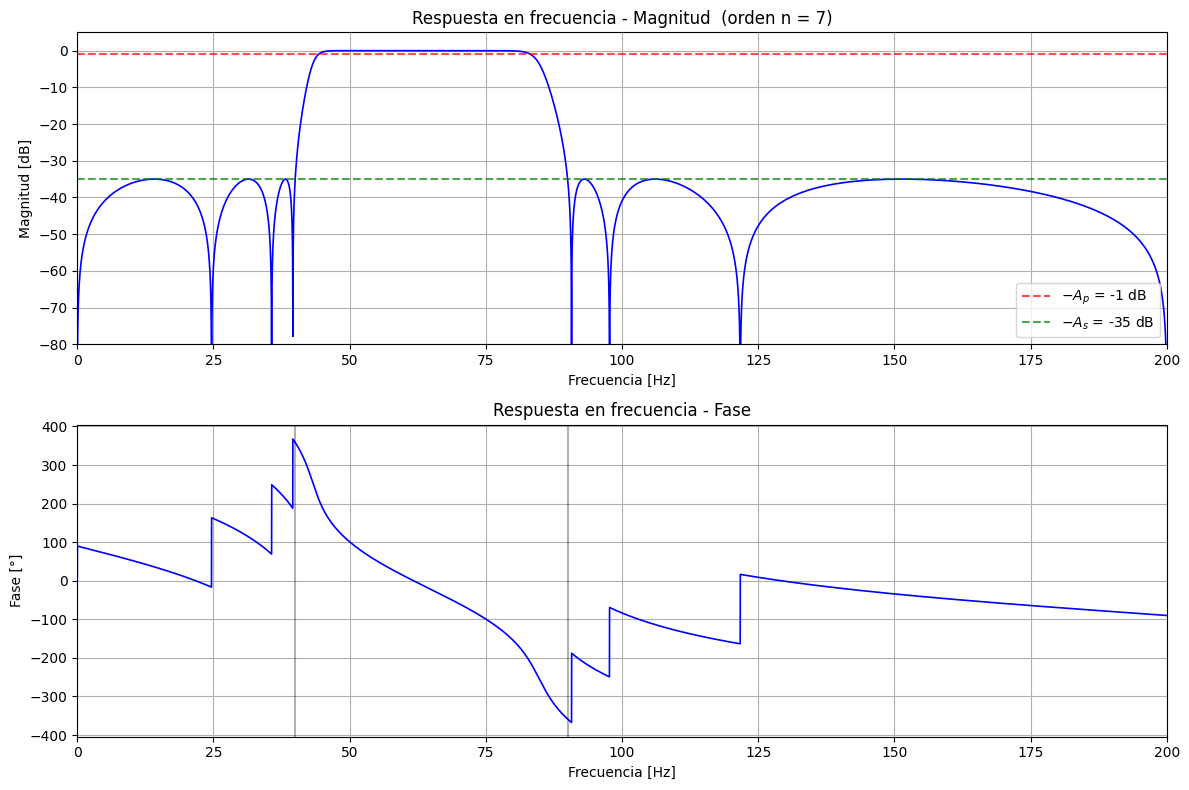

In [43]:
# Respuesta en frecuencia con freqz
N_freq = 8192
w, H = signal.freqz(b, a, worN=N_freq, fs=fs)

mag_dB = 20 * np.log10(np.abs(H) + 1e-12)
phase_deg = np.unwrap(np.angle(H)) * 180 / np.pi

fig, axes = plt.subplots(2, 1, figsize=[12, 8])

# --- Magnitud ---
axes[0].plot(w, mag_dB, 'b', linewidth=1.2)
axes[0].axhline(-gpass, color='red', linestyle='--', alpha=0.7, label=f'$-A_p$ = -{gpass:.0f} dB')
axes[0].axhline(-gstop, color='green', linestyle='--', alpha=0.7, label=f'$-A_s$ = -{gstop:.0f} dB')

axes[0].set_xlabel('Frecuencia [Hz]')
axes[0].set_ylabel('Magnitud [dB]')
axes[0].set_title(f'Respuesta en frecuencia - Magnitud  (orden n = {n_orden})')
axes[0].set_xlim([0, fs/2])
axes[0].set_ylim([-80, 5])
axes[0].grid(True)
axes[0].legend(loc='lower right')

# --- Fase ---
axes[1].plot(w, phase_deg, 'b', linewidth=1.2)
axes[1].axvline(fpass[0], color='k', linestyle='-', alpha=0.3)
axes[1].axvline(fpass[1], color='k', linestyle='-', alpha=0.3)
axes[1].set_xlabel('Frecuencia [Hz]')
axes[1].set_ylabel('Fase [°]')
axes[1].set_title('Respuesta en frecuencia - Fase')
axes[1].set_xlim([0, fs/2])
axes[1].grid(True)

plt.tight_layout()

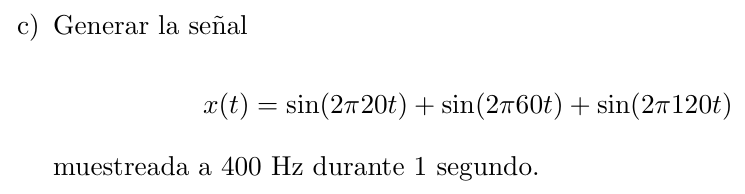

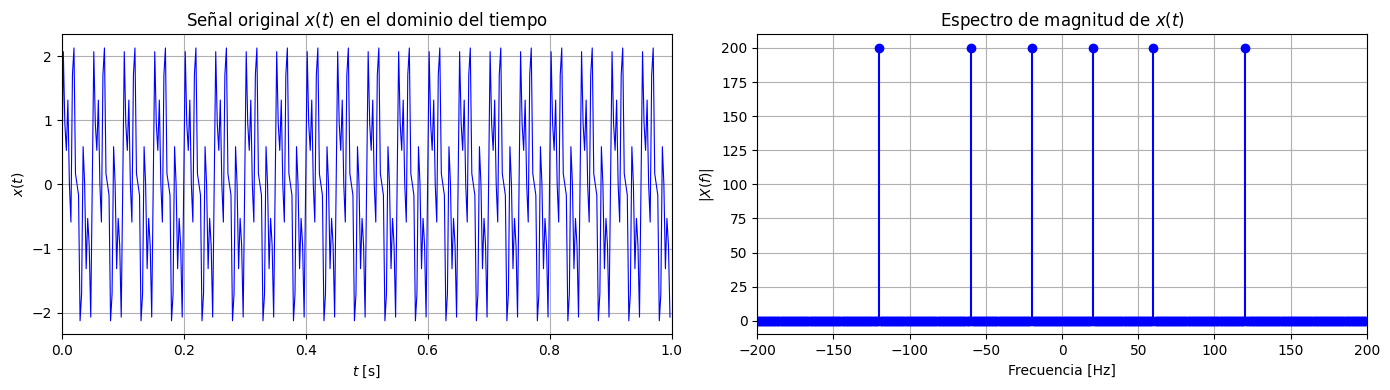

In [44]:
T = 1
n = np.arange(0, int(fs * T))
t = n / fs

# Tres componentes sinusoidales
f1, f2, f3 = 20, 60, 120
x = (np.sin(2*np.pi*f1*t) + np.sin(2*np.pi*f2*t) + np.sin(2*np.pi*f3*t))

fig, axes = plt.subplots(1, 2, figsize=[14, 4])

# Señal en el tiempo
axes[0].plot(t, x, 'b-', linewidth=0.8)
axes[0].set_xlabel('$t$ [s]')
axes[0].set_ylabel('$x(t)$')
axes[0].set_title('Señal original $x(t)$ en el dominio del tiempo')
axes[0].grid(True)
axes[0].set_xlim([0, T])

# Espectro de magnitud
Xw = np.fft.fftshift(np.fft.fft(x))
f_axis = (np.arange(len(n)) - len(n)/2) * fs / len(n)
axes[1].stem(f_axis, np.abs(Xw), basefmt=' ', linefmt='b-', markerfmt='bo')
axes[1].set_xlabel('Frecuencia [Hz]')
axes[1].set_ylabel('$|X(f)|$')
axes[1].set_title('Espectro de magnitud de $x(t)$')
axes[1].set_xlim([-fs/2, fs/2])
axes[1].grid(True)

plt.tight_layout()

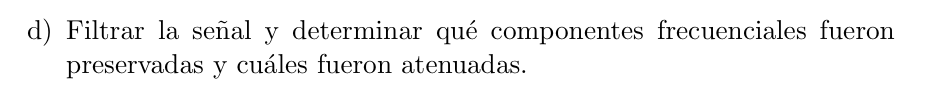

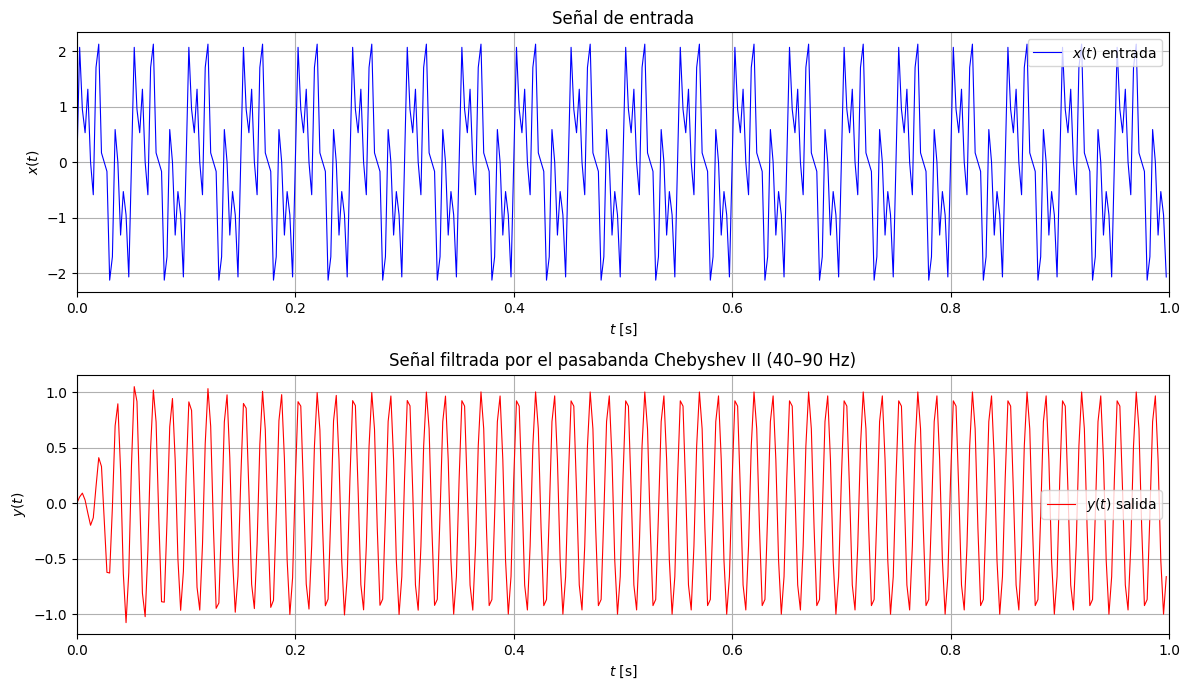

In [48]:
# Aplicamos el filtro
y = signal.lfilter(b, a, x)

fig, axes = plt.subplots(2, 1, figsize=[12, 7])

axes[0].plot(t, x, 'b-', linewidth=0.8, label='$x(t)$ entrada')
axes[0].set_xlabel('$t$ [s]')
axes[0].set_ylabel('$x(t)$')
axes[0].set_title('Señal de entrada')
axes[0].set_xlim([0, T])
axes[0].grid(True)
axes[0].legend()

axes[1].plot(t, y, 'r-', linewidth=0.8, label='$y(t)$ salida')
axes[1].set_xlabel('$t$ [s]')
axes[1].set_ylabel('$y(t)$')
axes[1].set_title('Señal filtrada por el pasabanda Chebyshev II (40–90 Hz)')
axes[1].set_xlim([0, T])
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()

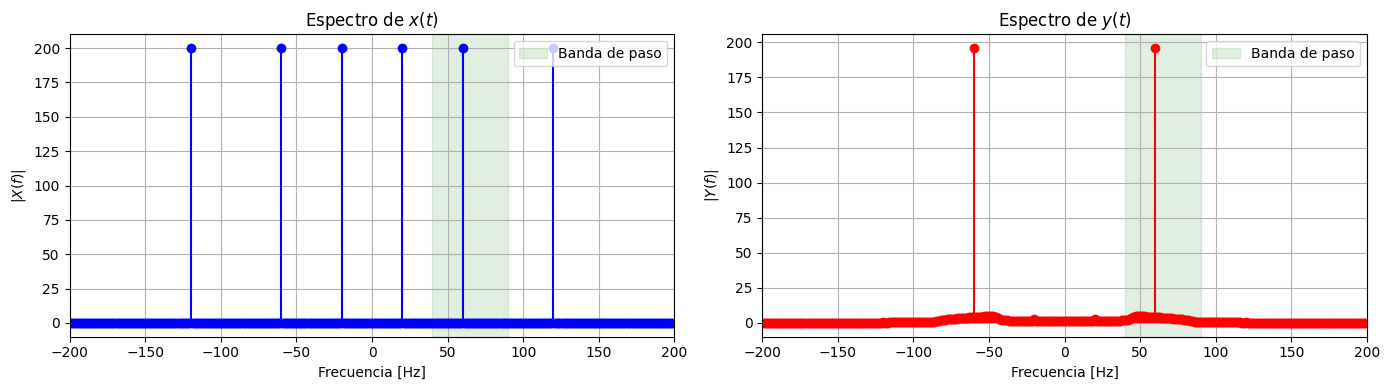

In [46]:
# Comparación de espectros de entrada y salida
Yw = np.fft.fftshift(np.fft.fft(y))

fig, axes = plt.subplots(1, 2, figsize=[14, 4])

# Espectro de entrada
axes[0].stem(f_axis, np.abs(Xw), basefmt=' ', linefmt='b-', markerfmt='bo')
axes[0].axvspan(fpass[0], fpass[1], color='green', alpha=0.12, label='Banda de paso')
axes[0].set_xlabel('Frecuencia [Hz]')
axes[0].set_ylabel('$|X(f)|$')
axes[0].set_title('Espectro de $x(t)$')
axes[0].set_xlim([-fs/2, fs/2])
axes[0].grid(True)
axes[0].legend(loc='upper right')

# Espectro de salida
axes[1].stem(f_axis, np.abs(Yw), basefmt=' ', linefmt='r-', markerfmt='ro')
axes[1].axvspan(fpass[0], fpass[1], color='green', alpha=0.12, label='Banda de paso')
axes[1].set_xlabel('Frecuencia [Hz]')
axes[1].set_ylabel('$|Y(f)|$')
axes[1].set_title('Espectro de $y(t)$')
axes[1].set_xlim([-fs/2, fs/2])
axes[1].grid(True)
axes[1].legend(loc='upper right')

plt.tight_layout()

In [47]:
# Cuantificación de la atenuación de cada componente
freqs_pos = f_axis[f_axis >= 0]
Xw_pos = np.abs(Xw[f_axis >= 0])
Yw_pos = np.abs(Yw[f_axis >= 0])

print(f"{'Componente':>12} | {'Banda':>10} | {'|X(f)|':>10} | {'|Y(f)|':>10} | {'Atenuación':>11} | {'Resultado'}")
print("-" * 80)
for fc in [f1, f2, f3]:
    idx = np.argmin(np.abs(freqs_pos - fc))
    x_amp = Xw_pos[idx]
    y_amp = Yw_pos[idx]
    if x_amp > 1e-6:
        att_db = 20 * np.log10(y_amp / x_amp)
    else:
        att_db = -np.inf
    in_band = (fc >= fpass[0]) and (fc <= fpass[1])
    estado = "PRESERVADA" if (in_band and att_db > -10) else ("ATENUADA" if (not in_band) else "ATENUADA")
    banda_txt = "PASABANDA" if in_band else "RECHAZADA"
    print(f"{fc:>8.0f} Hz  | {banda_txt:>10} | {x_amp:>10.3f} | {y_amp:>10.3f} | {att_db:>8.2f} dB | {estado}")

  Componente |      Banda |     |X(f)| |     |Y(f)| |  Atenuación | Resultado
--------------------------------------------------------------------------------
      20 Hz  |  RECHAZADA |    200.000 |      2.599 |   -37.73 dB | ATENUADA
      60 Hz  |  PASABANDA |    200.000 |    195.855 |    -0.18 dB | PRESERVADA
     120 Hz  |  RECHAZADA |    200.000 |      0.542 |   -51.34 dB | ATENUADA


### Resultados y comentarios

- El filtro Chebyshev Tipo II pasabanda de orden 7 (hallado mediante cheby2ord) satisface los requisitos de 1 dB de rizado en pasabanda y 35 dB de atenuación en rechazabanda dentro del rango 40–90 Hz.

- En la respuesta en frecuencia (magnitud) se observa claramente la banda de paso plana entre 40 y 90 Hz (≤ 1 dB), y la banda de rechazo con atenuación ≥ 35 dB fuera de este rango. El diagrama de polos y ceros muestra que los polos se encuentran dentro del círculo unitario (filtro estable) y los ceros se ubican sobre el círculo unitario.

- En el espectro de la señal filtrada $y(t)$ se observa que la componente de 60 Hz se preserva (dentro de la banda de paso), mientras que las componentes de 20 Hz y 120 Hz son atenuadas (> 35 dB de reducción). Esto confirma que el filtro deja pasar únicamente la frecuencia de interés.